# Amazon Delivery Dataset

**Feature Engineering**
**Tarefas**<br>
Remoção da temporalidade dos dados: agrupamento dos dados por critérios com métricas de agregação.<br>
Criação de uma coluna complementar de diferença de tempo entre order time e pickup.<br>
Criação de uma coluna de distancia a partir dos dados geolocalizados da loja a residência do cliente.<br>
Tratamento de valores nulos das colunas de order time e .<br>
Aplicação de um target encoding para feature de categoria de produtos.<br>
Encoding para feature de tempo.<br>

# Configuração

In [1]:
# carregamento de bibliotecas
import sys
import os
# Adiciona a pasta raiz do projeto (onde está a pasta src) ao sys.path
sys.path.append(os.path.abspath(os.path.join("..")))
# comando autoreload dos módulos de funções
%load_ext autoreload
%autoreload 2
from src.config.logging_config import setup_logging
from src.data.load_data import carregar_dataset
from src.data.processing import *
from src.utils.statistics import *
from src.visualization.plot import *

In [2]:
# configurações de logging
setup_logging()

# Exploração Inicial

In [3]:
# carregamento dos dados
tbl_amazon_dlv = carregar_dataset('../data/raw/amazon_delivery.csv',sep=',')

2025-09-17 01:17:37,330 | INFO | src.data.load_data | Captura do arquivo no path:../data/raw/amazon_delivery.csv


In [4]:
# amostragem dos dados do dataset listings
amostra_dados(tbl_amazon_dlv)


,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
42722,kqld417994775,31,4.5,13.005801,80.250744,13.095801,80.340744,2022-03-06,19:55:00,20:00:00,Stormy,Jam,motorcycle,Metropolitian,215,Cosmetics
36604,bsjn226424951,25,4.3,22.761226,75.887522,22.841226,75.967522,2022-03-14,20:30:00,20:35:00,Cloudy,Jam,scooter,Urban,190,Shoes
23530,vexv853978306,21,4.8,12.321214,76.621094,12.401214,76.701094,2022-03-23,19:35:00,19:50:00,Sunny,Jam,motorcycle,Metropolitian,150,Jewelry


**Presença de dados nulos no dataset inicial.**<br>

**Dados temporais:**<br>
** Order_Date no formato datetime (yyyy-mm--dd) no formato texto, como uma coluna.**
** Order_Time e Pickup_time no fomato hora (hh:mm:ss) no formato texto.

In [5]:
# informações do dataset tbl_amazon_dlv
tbl_amazon_dlv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43739 entries, 0 to 43738
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         43739 non-null  object 
 1   Agent_Age        43739 non-null  int64  
 2   Agent_Rating     43685 non-null  float64
 3   Store_Latitude   43739 non-null  float64
 4   Store_Longitude  43739 non-null  float64
 5   Drop_Latitude    43739 non-null  float64
 6   Drop_Longitude   43739 non-null  float64
 7   Order_Date       43739 non-null  object 
 8   Order_Time       43739 non-null  object 
 9   Pickup_Time      43739 non-null  object 
 10  Weather          43648 non-null  object 
 11  Traffic          43739 non-null  object 
 12  Vehicle          43739 non-null  object 
 13  Area             43739 non-null  object 
 14  Delivery_Time    43739 non-null  int64  
 15  Category         43739 non-null  object 
dtypes: float64(5), int64(2), object(9)
memory usage: 5.3+ MB


## transformação dos tipos de dados para exploração do dataset

In [6]:
# transformação do tipo de dado da coluna para o formato datetime
tbl_amazon_dlv['Order_Date'] = pd.to_datetime(tbl_amazon_dlv['Order_Date'])
tbl_amazon_dlv['Order_Time'] = pd.to_datetime(tbl_amazon_dlv['Order_Time'], format='%H:%M:%S', errors='coerce').dt.time
tbl_amazon_dlv['Pickup_Time'] = pd.to_datetime(tbl_amazon_dlv['Pickup_Time'], format='%H:%M:%S', errors='coerce').dt.time

In [7]:
# feature extraction entre a diferença da data do pedido e tempo de coleta
tbl_amazon_dlv['tempo_coleta'] = pd.to_timedelta(tbl_amazon_dlv['Pickup_Time'].astype(str)) - pd.to_timedelta(tbl_amazon_dlv['Order_Time'].astype(str))
tbl_amazon_dlv['tempo_coleta_min'] = (
    tbl_amazon_dlv['tempo_coleta'].dt.total_seconds() / 60
).astype('Int64')

tbl_amazon_dlv['tempo_coleta_min'] = tbl_amazon_dlv['tempo_coleta_min'].mask(
    tbl_amazon_dlv['tempo_coleta_min'] < 0,
    tbl_amazon_dlv['tempo_coleta_min'] + (24 * 60)
)


In [8]:
# feature extraction do tempo total desde à colocação do pedido a entrega ao cliente em minutos
tbl_amazon_dlv['tempo_total_pedido'] = tbl_amazon_dlv['Delivery_Time'] + tbl_amazon_dlv['tempo_coleta_min']

## Feature Extraction para redução de temporalidade dos dados: PIPELINE


In [9]:
# transformação da coluna para o tipo int para interpretação pelo modelo
tbl_amazon_dlv = dados_temporais(df=tbl_amazon_dlv, data=tbl_amazon_dlv['Order_Date'])
tbl_amazon_dlv.Feriado = tbl_amazon_dlv.Feriado.astype('int64')

c:\Users\ederr\Documents\PROJETOS_PYTHON\projetos_fiap\Fase 3\tech_challenge_ml_engineer_phase3\.venv\Lib\site-packages\holidays\countries\india.py:182: Warning: Requested Holidays are available only from 2001 to 2035.
  warnings.warn(warning_msg, Warning)


In [10]:
# transformação senoidal das colunas temporais para melhoria do processo de entendimento do fim dos ciclos de calendário
tbl_amazon_dlv = transformacao_ciclica(df=tbl_amazon_dlv,dias_uteis=False)

2025-09-17 01:17:38,810 | INFO | src.data.processing | Transformação cíclica para as colunas de dados temporais.


## **Identificação de Valores nulos**<br>
Agent_age e Weather concentram os valores nulos do dataset.
Temos 145 linhas contendo a combinação de valores nulos.
Nulos representam 20% da feature weather, enquanto Agent_Rating represrnta 12%

In [11]:
# verificação de nulos
verificacao_nulos(df=tbl_amazon_dlv)

Order_ID               0
Agent_Age              0
Agent_Rating          54
Store_Latitude         0
Store_Longitude        0
Drop_Latitude          0
Drop_Longitude         0
Order_Date             0
Order_Time            91
Pickup_Time            0
Weather               91
Traffic                0
Vehicle                0
Area                   0
Delivery_Time          0
Category               0
tempo_coleta          91
tempo_coleta_min      91
tempo_total_pedido    91
dayofweek              0
month                  0
Feriado                0
day_sin                0
day_cos                0
month_sin              0
month_cos              0
dtype: int64

In [12]:
# frequência de nulos
frequencia_valores_nulos(df=tbl_amazon_dlv)

,missing,total,percent
Order_Time,91,43739,0.208052
Weather,91,43739,0.208052
tempo_total_pedido,91,43739,0.208052
tempo_coleta,91,43739,0.208052
tempo_coleta_min,91,43739,0.208052
Agent_Rating,54,43739,0.123460
Agent_Age,0,43739,0.000000
Order_ID,0,43739,0.000000
Store_Longitude,0,43739,0.000000
Store_Latitude,0,43739,0.000000


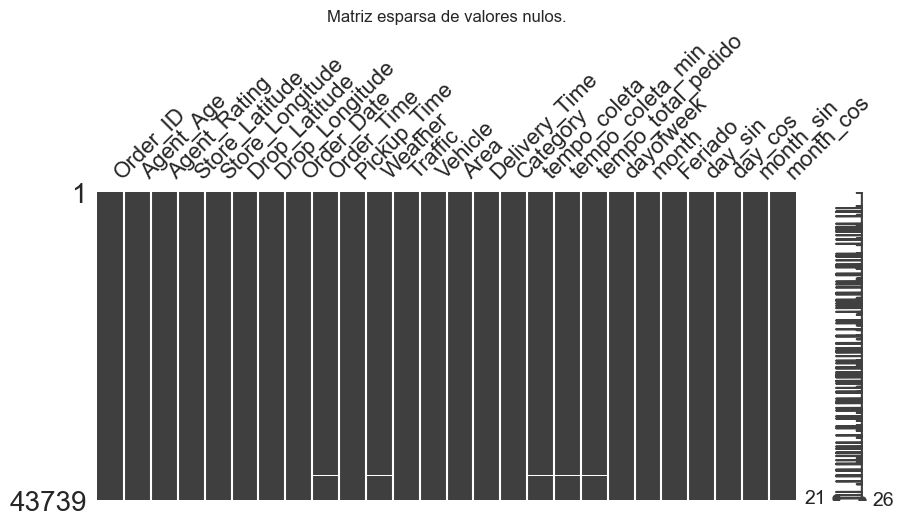

In [13]:
# matriz de linhas nulas
matriz_valores_nulos(df=tbl_amazon_dlv)

In [14]:
# filtragem das linhas com valores nulos
valores_nulos = filtrar_linhas_valores_nulos(df=tbl_amazon_dlv)
valores_nulos

2025-09-17 01:17:39,857 | INFO | src.data.processing | Contagem de linhas nulas para o dataframe:145


,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,...,tempo_coleta,tempo_coleta_min,tempo_total_pedido,dayofweek,month,Feriado,day_sin,day_cos,month_sin,month_cos
124,uurs547552548,23,NaN,22.569358,88.433452,22.599358,88.463452,2022-02-17,23:25:00,23:35:00,...,0 days 00:10:00,10,85,3,2,0,0.433884,-0.900969,0.866025,5.000000e-01
1996,xoaj834389107,32,NaN,0.000000,0.000000,0.050000,0.050000,2022-02-11,20:50:00,21:00:00,...,0 days 00:10:00,10,195,4,2,0,-0.433884,-0.900969,0.866025,5.000000e-01
2002,lasr795083832,23,NaN,25.454648,81.834502,25.584648,81.964502,2022-02-18,19:50:00,19:55:00,...,0 days 00:05:00,5,155,4,2,0,-0.433884,-0.900969,0.866025,5.000000e-01
2018,gjcr517387117,26,NaN,0.000000,0.000000,0.080000,0.080000,2022-02-16,23:50:00,23:55:00,...,0 days 00:05:00,5,145,2,2,0,0.974928,-0.222521,0.866025,5.000000e-01
2286,xige084493792,15,1.0,-26.891191,75.802083,26.981191,75.892083,2022-03-12,NaT,17:20:00,...,NaT,<NA>,<NA>,5,3,0,-0.974928,-0.222521,1.000000,6.123234e-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41504,ogxf318978500,20,NaN,25.451517,81.832616,25.501517,81.882616,2022-02-13,22:15:00,22:30:00,...,0 days 00:15:00,15,100,6,2,0,-0.781831,0.623490,0.866025,5.000000e-01
42598,llox673359294,15,1.0,0.000000,0.000000,0.070000,0.070000,2022-03-14,NaT,17:40:00,...,NaT,<NA>,<NA>,0,3,0,0.000000,1.000000,1.000000,6.123234e-17
43027,qhka163034669,20,NaN,22.514585,88.393310,22.594585,88.473310,2022-02-14,22:20:00,22:25:00,...,0 days 00:05:00,5,105,0,2,0,0.000000,1.000000,0.866025,5.000000e-01
43053,ifig993965994,15,1.0,13.086438,80.220672,13.216439,80.350672,2022-03-18,NaT,18:00:00,...,NaT,<NA>,<NA>,4,3,0,-0.433884,-0.900969,1.000000,6.123234e-17


In [15]:
# tratamento do dataset sem a presença de valores nulos
tbl_amazon_dlv = tbl_amazon_dlv.loc[
    ~tbl_amazon_dlv.index.isin(valores_nulos.index)
]

## Verificação de linhas duplicadas<br>
Tecnicamente o dataset corresponde a um pedido exclusivo, validado pela quantidade de pedidos para cada id. Espera-se que o id seja exclusivo para cada pedido. 

In [16]:
# verificação de linhas duplicadas
verificar_linhas_duplicadas(df=tbl_amazon_dlv)

,,,,,,,,,,,,,,,,,,,,,,,,,,n_duplicates
Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category,tempo_coleta,tempo_coleta_min,tempo_total_pedido,dayofweek,month,Feriado,day_sin,day_cos,month_sin,month_cos,


## Verificação de exclusividade dos pedidos

In [17]:
# verificação de exclusividade dos pedidos
qtde_pedido_por_id = tbl_amazon_dlv.Order_ID.value_counts()
set(qtde_pedido_por_id)

{1}

## Verificação dos dados de geolocalização
Erro de valores dos dados de geolocalização resultando em pontos fora do mapa da operação.

In [18]:
# Crie um DataFrame para a visualização, unindo os dados
dados_geoloc = pd.DataFrame()
dados_geoloc['latitude'] = pd.concat([tbl_amazon_dlv['Store_Latitude'], tbl_amazon_dlv['Drop_Latitude']])
dados_geoloc['longitude'] = pd.concat([tbl_amazon_dlv['Store_Longitude'], tbl_amazon_dlv['Drop_Longitude']])

gerar_mapa_scatter_plot(df=dados_geoloc,
    lat_col="latitude",
    lon_col="longitude",
    height=600,
    title='Visualização dos dados geolocalização das entregas',
    jitter_amount=0.000,
)



In [19]:
# tratamento dos valores de geolocalização
tbl_amazon_dlv['Store_Latitude'] = np.abs(tbl_amazon_dlv['Store_Latitude'])
tbl_amazon_dlv['Store_Longitude'] = np.abs(tbl_amazon_dlv['Store_Longitude'])
tbl_amazon_dlv['Drop_Latitude'] = np.abs(tbl_amazon_dlv['Drop_Latitude'])
tbl_amazon_dlv['Drop_Longitude'] = np.abs(tbl_amazon_dlv['Drop_Longitude'])

C:\Users\ederr\AppData\Local\Temp\ipykernel_36316\729082461.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\ederr\AppData\Local\Temp\ipykernel_36316\729082461.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\ederr\AppData\Local\Temp\ipykernel_36316\729082461.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-d

In [20]:
# verificação dos dados de geolocalização fora do país de origem dos dados
dados_tratamento_valores_geolocalizacao = filtrar_dataset(df=tbl_amazon_dlv, query="Store_Longitude <70 | Drop_Longitude <70")


In [21]:
# filtragem do dataset com os dados que necessitam de tratamento de valores de geolocalização por alguma métrica
tbl_amazon_dlv = tbl_amazon_dlv.loc[
    ~tbl_amazon_dlv.index.isin(dados_tratamento_valores_geolocalizacao.index)
]


In [22]:
# visualização da correção dos dados de geolocalização
dados_geoloc = pd.DataFrame()
dados_geoloc['latitude'] = pd.concat([tbl_amazon_dlv['Store_Latitude'], tbl_amazon_dlv['Drop_Latitude']])
dados_geoloc['longitude'] = pd.concat([tbl_amazon_dlv['Store_Longitude'], tbl_amazon_dlv['Drop_Longitude']])

gerar_mapa_scatter_plot(df=dados_geoloc,
    lat_col="latitude",
    lon_col="longitude",
    height=600,
    title='Visualização dos dados geolocalização das entregas',
    jitter_amount=0.000,
)

In [23]:
# feature extraction da distancia entre os pontos de coleta e entrega das mercadorias
tbl_amazon_dlv['distancia_entrega'] = tbl_amazon_dlv.apply(
    lambda row: distancia_dados_geolocalizacao(
        p1_lat=row['Store_Latitude'], 
        p1_lgt=row['Store_Longitude'],
        p2_lat=row['Drop_Latitude'], 
        p2_lgt=row['Drop_Longitude']
    ),
    axis=1
)

In [24]:
# feature extraction da velocidade media de entrega 
tbl_amazon_dlv['tempo_deslocamento_h'] = (tbl_amazon_dlv['Delivery_Time'] / 60)
tbl_amazon_dlv['veloc_media'] = tbl_amazon_dlv['distancia_entrega'] / tbl_amazon_dlv['tempo_deslocamento_h']


## Tratamento de caracteres de feature categórica

In [25]:
# tratamento dos valores das coluna traffic para remoção de caracteres vazios
tbl_amazon_dlv['Traffic'] = tbl_amazon_dlv['Traffic'].str.rstrip(' ')

## Definição de uma política de OTD (On-time-delivery)
Analisando o gráfico abaixo percebemos que apesar da variação das condições de distância, tempo, tráfego e clima, os pedidos não ultrapassam 300 minutos de dispersão entre tempo e distância.
Portanto, definimos o OTD até 300 minutos.

In [26]:
otd_atual = (tbl_amazon_dlv['tempo_total_pedido'] <=120).mean()*100
otd_atual

np.float64(41.706350195716674)

<Figure size 1200x800 with 0 Axes>

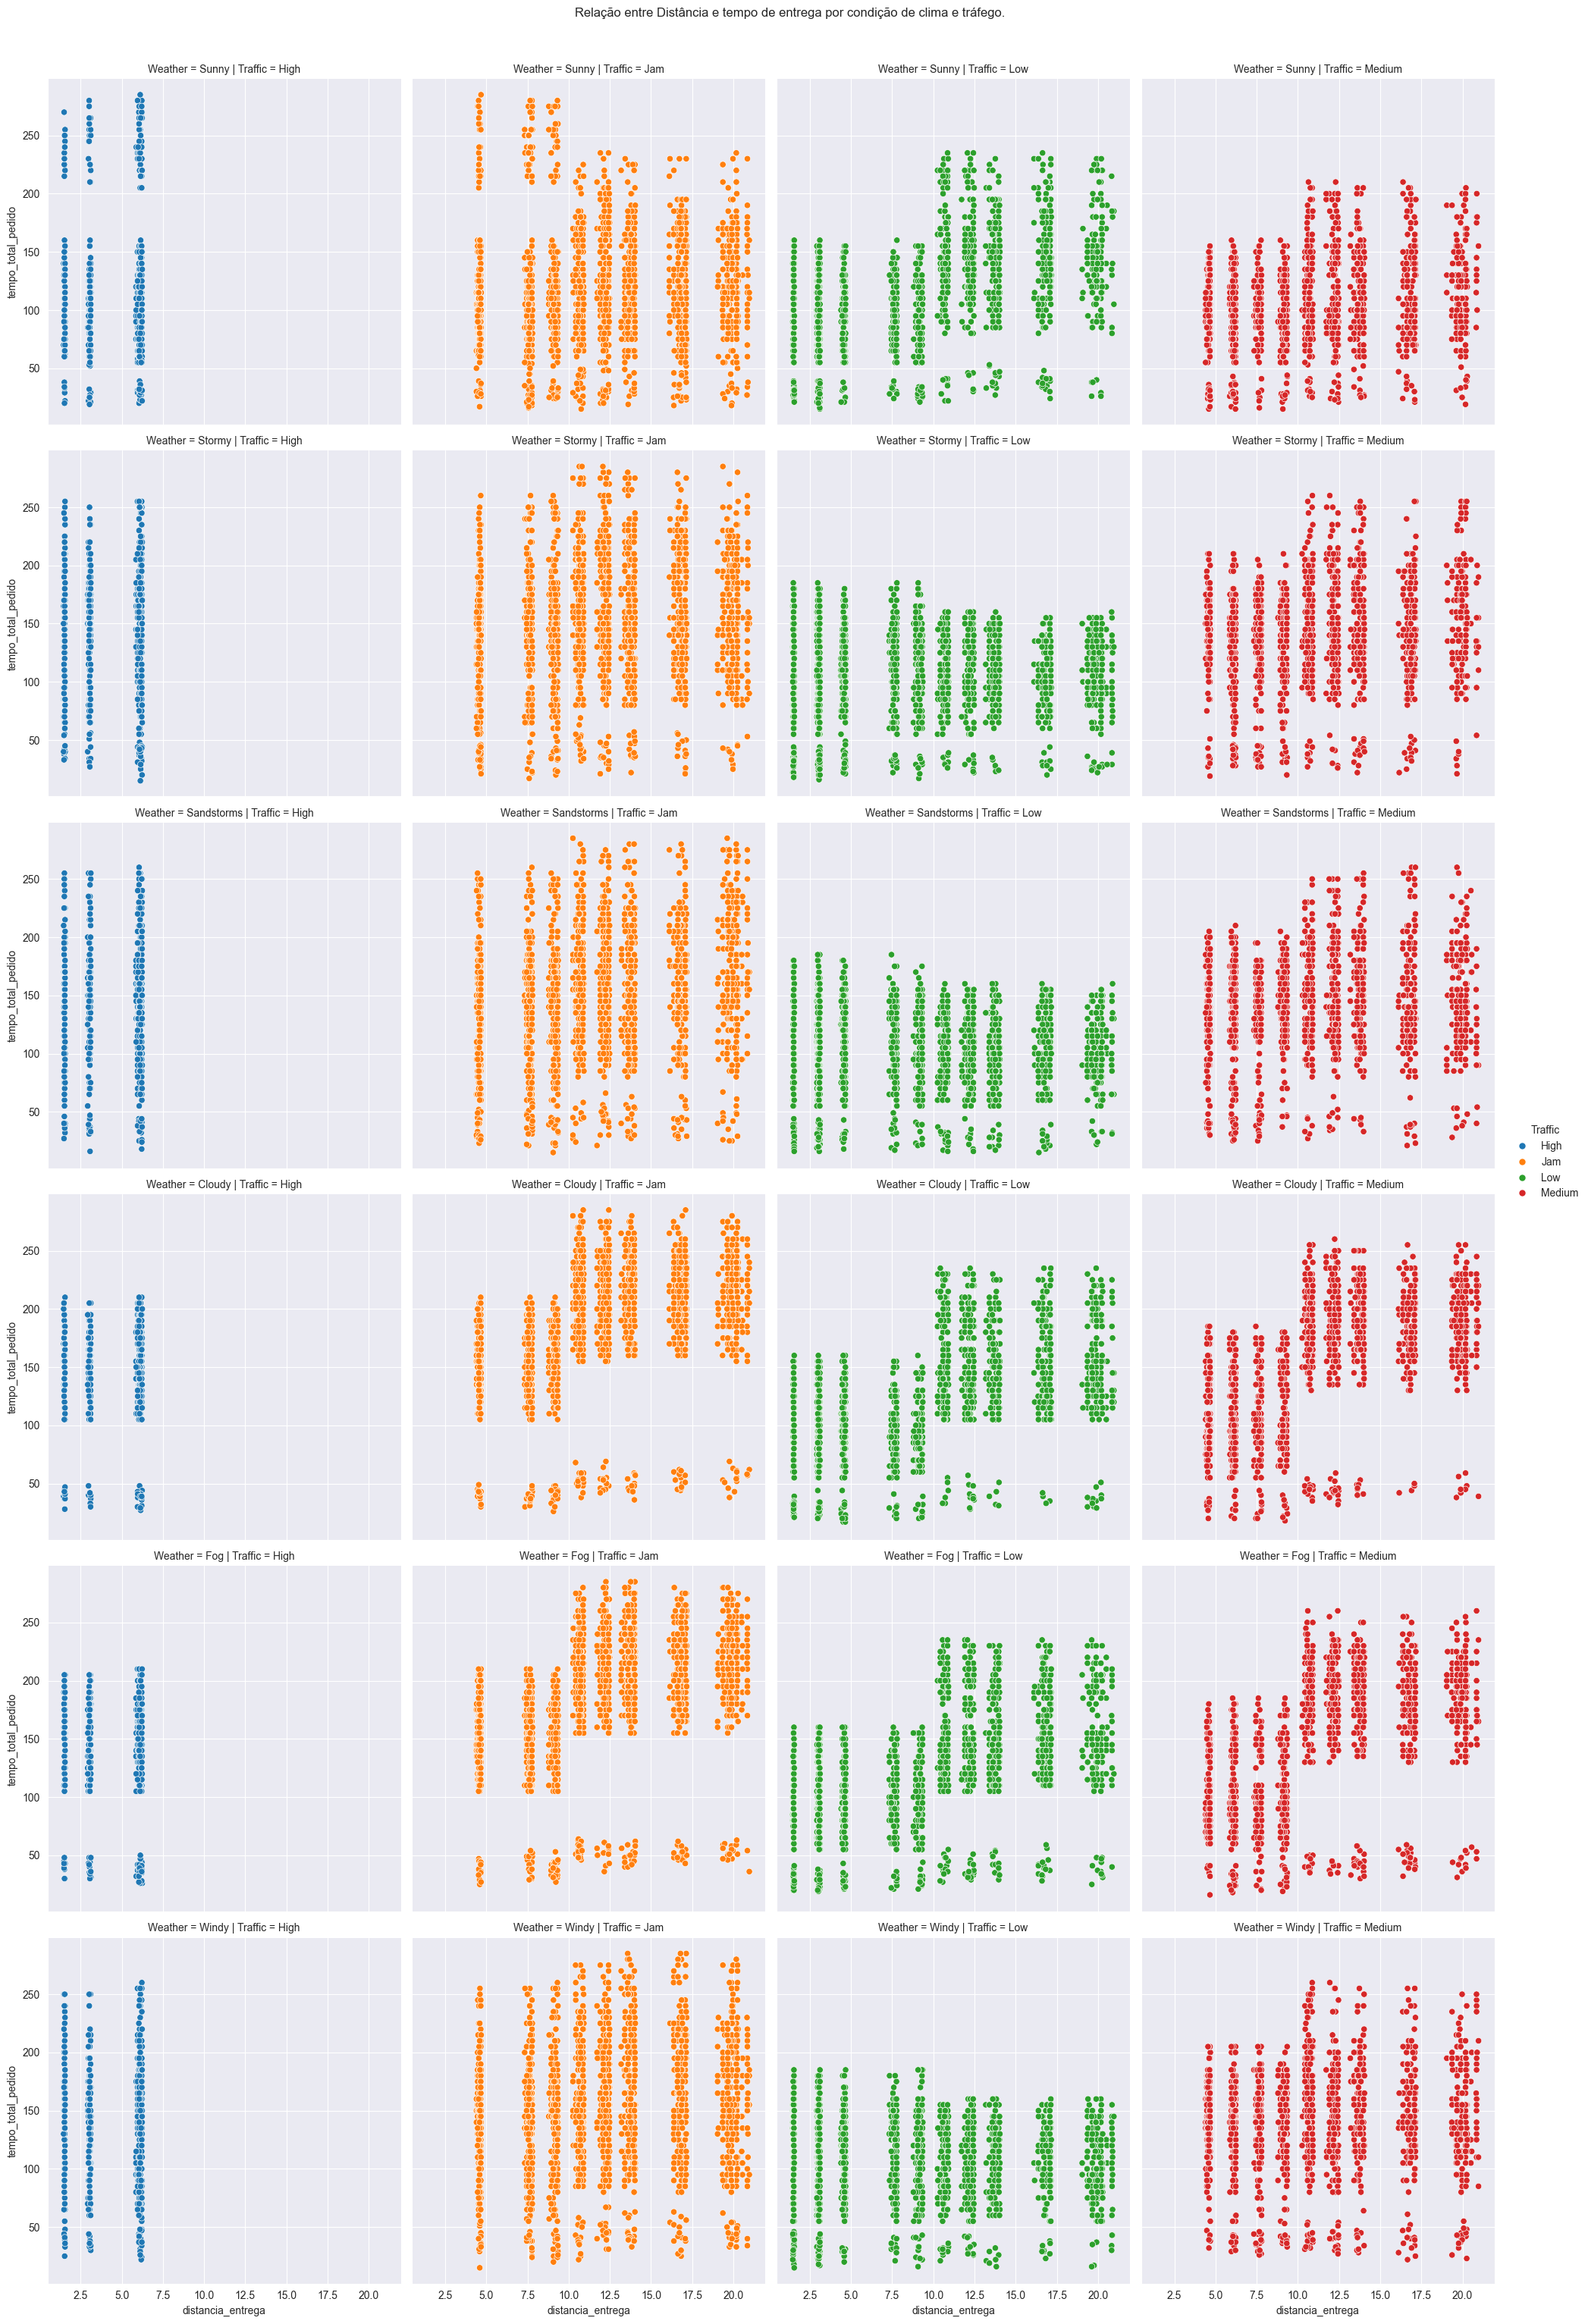

In [27]:
# análise da dispersão dos dados pela relação entre distância e tempo por condição de tempo e tráfego
grafico_replot(df=tbl_amazon_dlv, x='distancia_entrega',y='tempo_total_pedido', col_div='Traffic', linha_div='Weather', 
               hue='Traffic', titulo='Relação entre Distância e tempo de entrega por condição de clima e tráfego.')



In [28]:
# Inverte os valores da coluna
tbl_amazon_dlv['is_grocery'] = np.where(tbl_amazon_dlv['Category'] == 'Grocery', 1, 0)

# Cópia do dataset para transformações presentes no pipeline
Evitar data leakage e validar as transformações

In [29]:
tbl_amazon_dlv_eda = tbl_amazon_dlv.copy()

## Seleção de colunas para análise 

In [30]:
features_selecionadas = ['Agent_Age', 'Agent_Rating','Weather', 'Traffic', 'Vehicle', 'Area','Delivery_Time', 'Category','tempo_coleta_min',
       'distancia_entrega', 'veloc_media','day_sin',
       'day_cos', 'month_sin', 'month_cos','is_grocery','tempo_total_pedido']

In [31]:
# selecao de colunas para validacao de transformações do pipeline
tbl_amazon_dlv_eda = selecao_colunas(df=tbl_amazon_dlv_eda, colunas=features_selecionadas)

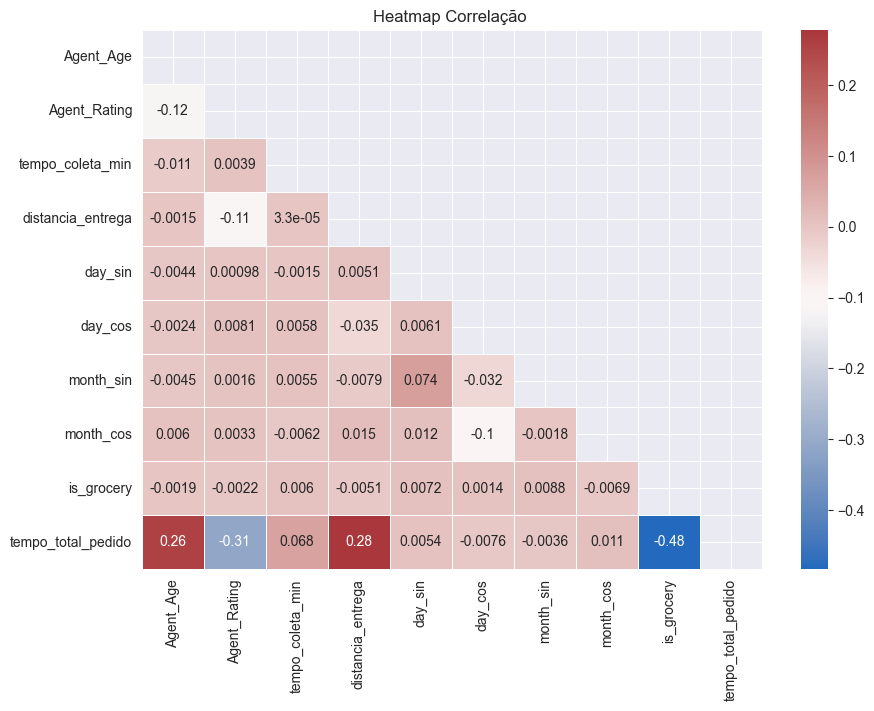

In [32]:
grafico_heatmap(tbl_amazon_dlv_eda.drop(['veloc_media','Delivery_Time'],axis=1))

## encoding dos dados 


**Dados categorizados que não apresentam ordenação**<br>
Alta quantidade de categorias para feature Category: esparcidade dos dados e necessidade de aplicar um target encoder.
Equilíbrio na frequência por categoria.

In [33]:
# quantidade de pedidos por condição de tempo
qtde_pedidos_por_transito = tbl_amazon_dlv.Traffic.value_counts()
qtde_pedidos_por_transito

Traffic
Low       13739
Jam       12647
Medium     9774
High       3949
Name: count, dtype: int64

In [34]:
# contagem de categoria de produtos
qtde_pedidos_por_categoria = tbl_amazon_dlv_eda.Category.value_counts()
qtde_pedidos_por_categoria

Category
Electronics     2618
Jewelry         2580
Books           2579
Toys            2567
Skincare        2558
Outdoors        2535
Snacks          2518
Apparel         2501
Home            2484
Sports          2481
Pet Supplies    2463
Cosmetics       2454
Grocery         2453
Shoes           2446
Kitchen         2444
Clothing        2428
Name: count, dtype: int64

In [35]:
# quantidade de pedidos por condição de tempo
qtde_pedidos_por_clima = tbl_amazon_dlv_eda.Weather.value_counts()
qtde_pedidos_por_clima

Weather
Fog           6805
Stormy        6773
Cloudy        6693
Sandstorms    6676
Windy         6638
Sunny         6524
Name: count, dtype: int64

In [36]:
# quantidade de pedidos por condição de transito
qtde_pedidos_por_transito = tbl_amazon_dlv_eda.Traffic.value_counts()
qtde_pedidos_por_transito

Traffic
Low       13739
Jam       12647
Medium     9774
High       3949
Name: count, dtype: int64

In [37]:
# quantidade de pedidos por área de entrega
qtde_pedidos_por_area = tbl_amazon_dlv_eda.Area.value_counts()
qtde_pedidos_por_area

Area
Metropolitian     30030
Urban              8891
Other              1050
Semi-Urban          138
Name: count, dtype: int64

In [38]:
# quantidade de pedidos por tipo de veiculo
qtde_pedidos_por_veiculo = tbl_amazon_dlv_eda.Vehicle.value_counts()
qtde_pedidos_por_veiculo

Vehicle
motorcycle     23530
scooter        13389
van             3190
Name: count, dtype: int64

**Target Encoder: PIPELINE**

In [39]:
# target encoder para redução de dimensionalidade da feature Category
feature_target_encoding = target_encoding(feature='Category', 
                                                  dados_ajuste=tbl_amazon_dlv_eda.drop('tempo_total_pedido', axis=1), target=tbl_amazon_dlv_eda['tempo_total_pedido'])

tbl_amazon_dlv_eda.update(feature_target_encoding)

In [40]:
# visualização do processo de target encoding para os valores da coluna category
tbl_amazon_dlv_eda.Category.value_counts()

Category
141.195569    2618
140.494186    2580
141.077937    2579
139.427347    2567
142.472635    2558
141.524655    2535
142.057188    2518
141.967213    2501
141.058776    2484
142.470778    2481
141.747868    2463
143.06846     2454
36.56543      2453
141.150859    2446
142.219722    2444
140.422158    2428
Name: count, dtype: int64

### **ONE HOT ENCODING: PIPELINE**

In [41]:
# encoding das demais features categóricas que apresentam baixa dimensionalidade
features_encoded = one_hot_encoding(dados_ajuste=tbl_amazon_dlv_eda[['Weather','Traffic','Vehicle','Area']], target=tbl_amazon_dlv_eda['tempo_total_pedido']).reset_index(drop=True)


In [42]:
# juncao do dataset com a tabela de analise
tbl_amazon_dlv_eda = pd.concat([tbl_amazon_dlv_eda.drop(['Weather','Traffic','Vehicle','Area'], axis=1).reset_index(drop=True), features_encoded], axis=1)

In [43]:
# visualização dos dados após processo de encoding dos dados
tbl_amazon_dlv_eda.head()

,Agent_Age,Agent_Rating,Delivery_Time,Category,tempo_coleta_min,distancia_entrega,veloc_media,day_sin,day_cos,month_sin,...,Traffic_Jam,Traffic_Low,Traffic_Medium,Vehicle_motorcycle,Vehicle_scooter,Vehicle_van,Area_Metropolitian,Area_Other,Area_Semi-Urban,Area_Urban
0,37,4.9,120,140.422158,15,3.025154,1.512577,-0.974928,-0.222521,1.000000,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,34,4.5,165,141.195569,5,20.183558,7.339476,-0.433884,-0.900969,1.000000,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,23,4.4,130,142.470778,15,1.552760,0.716658,-0.974928,-0.222521,1.000000,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,38,4.7,105,143.06846,10,7.790412,4.451664,0.781831,0.623490,0.866025,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,32,4.6,150,139.427347,15,6.210147,2.484059,-0.974928,-0.222521,1.000000,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


## analise da distribuicao dos dados

2025-09-17 01:17:52,068 | INFO | src.visualization.plot | Método de escalonamento: StandardScaler


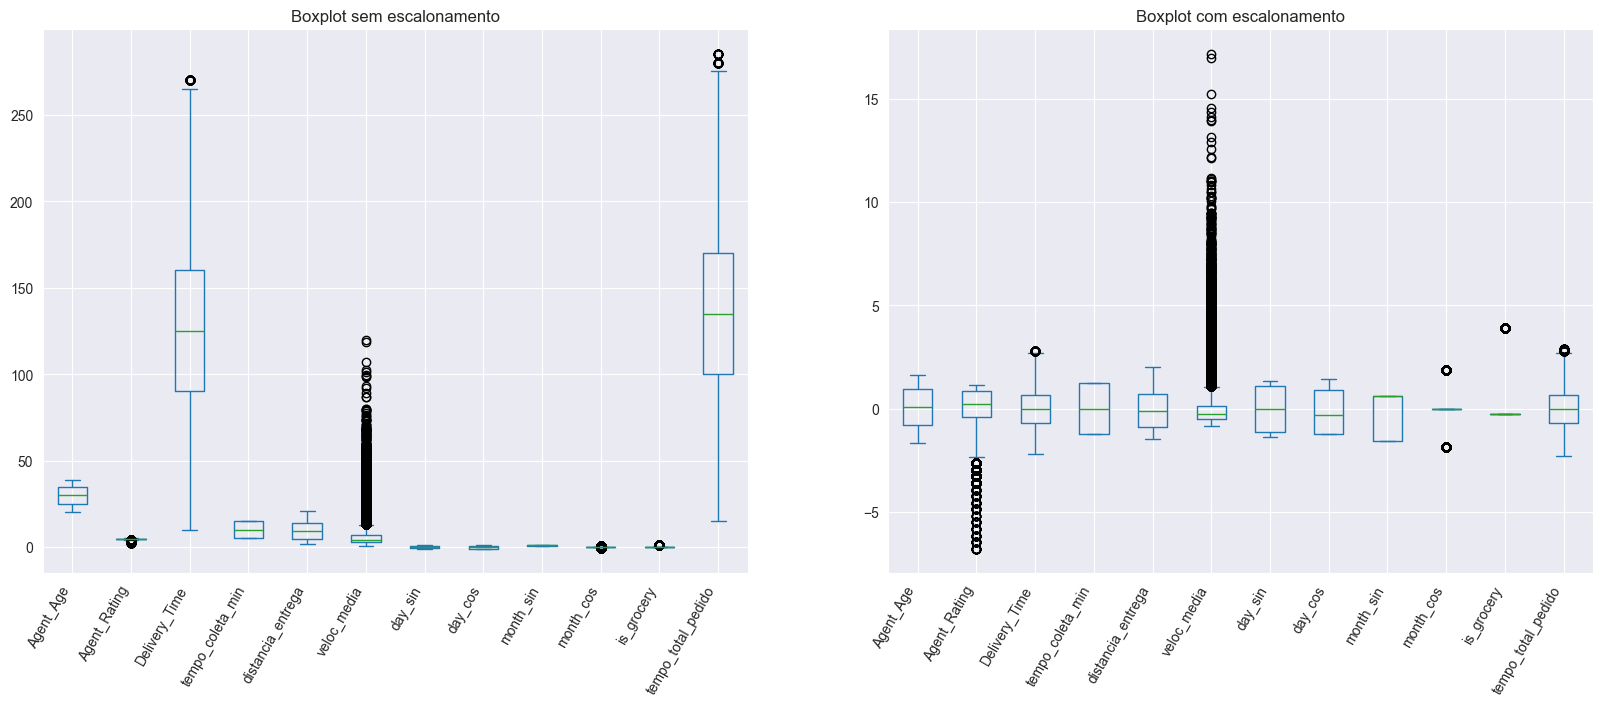

In [44]:
# gráfico boxplot para comparar a distribuição dos dados numericos com o escalonamento
boxplot_comparativo_escalonamento_dados(df=tbl_amazon_dlv_eda.drop(features_encoded.columns,axis=1))

### Hipótese de normalidade dos dados


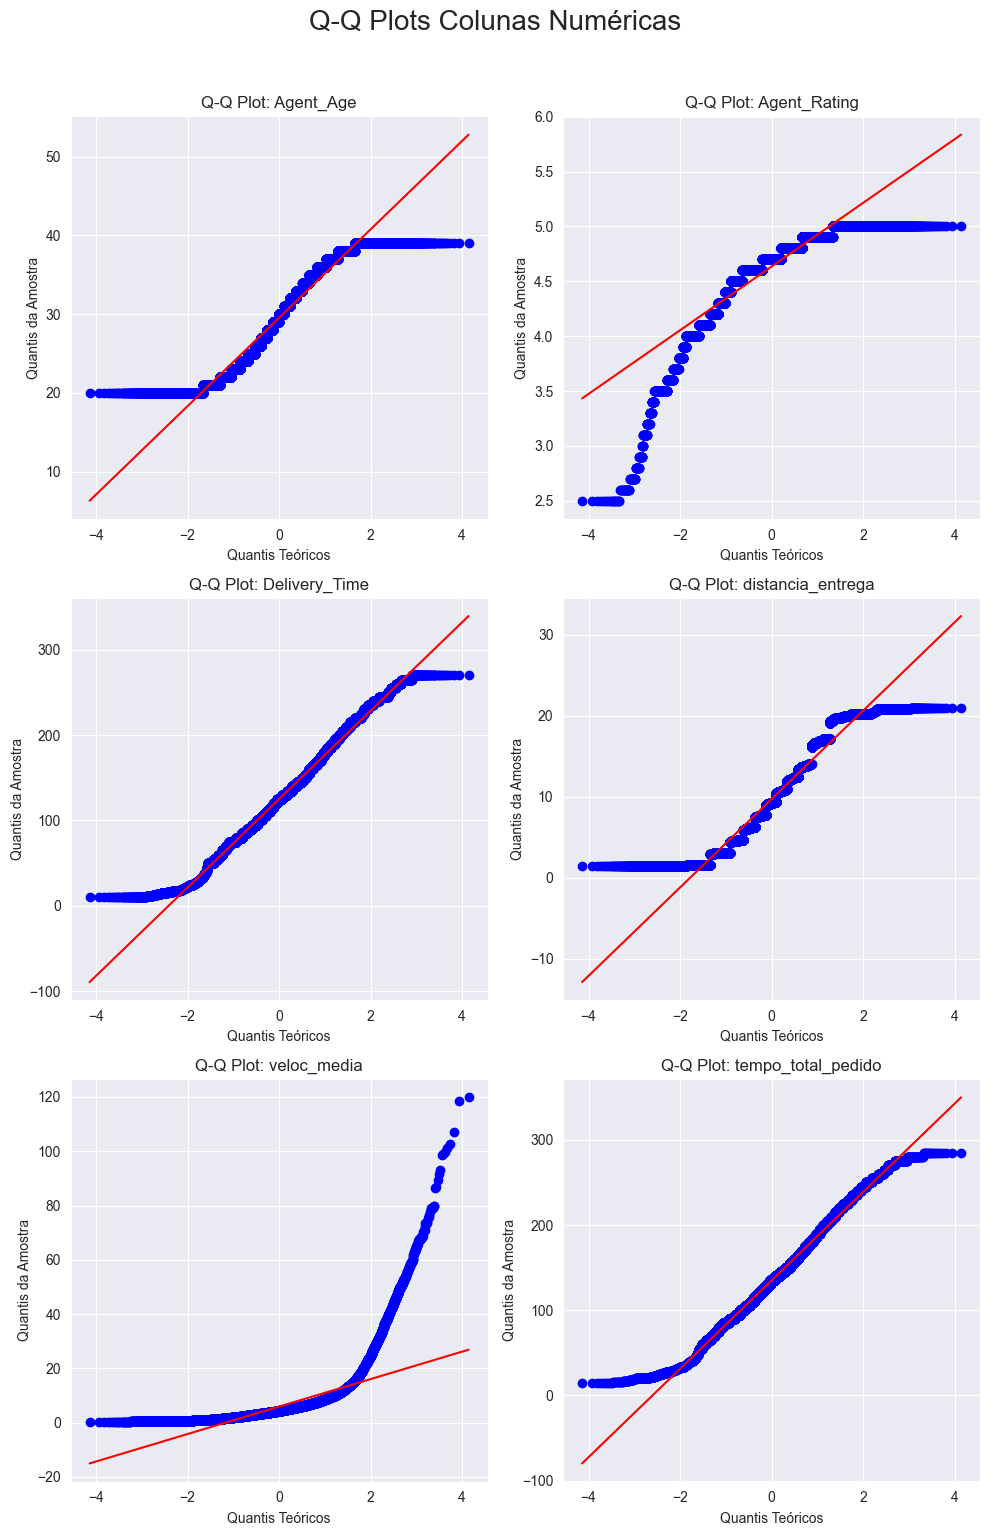

In [45]:
grafico_qq_plot(tbl_amazon_dlv_eda[['Agent_Age','Agent_Rating', 'Delivery_Time', 'distancia_entrega',
       'veloc_media', 'tempo_total_pedido']])

In [46]:
# aplicação de teste estatístico ara validação dos dados
teste_normalidade(df=tbl_amazon_dlv_eda,feature='Delivery_Time', num_cols=['Agent_Age','Agent_Rating', 'Delivery_Time', 'distancia_entrega',
       'veloc_media', 'tempo_total_pedido'])

,Categoria,Coluna,N,Teste,Estatística,p-value,Normal?
0,Geral,Agent_Age,40109,Kolmogorov-Smirnov,0.084302,1.965657e-248,Não
1,Geral,Agent_Rating,40109,Kolmogorov-Smirnov,0.195187,0.000000e+00,Não
2,Geral,Delivery_Time,40109,Kolmogorov-Smirnov,0.044973,6.227658e-71,Não
3,Geral,distancia_entrega,40109,Kolmogorov-Smirnov,0.091108,3.612496e-290,Não
4,Geral,veloc_media,40109,Kolmogorov-Smirnov,0.206122,0.000000e+00,Não
5,Geral,tempo_total_pedido,40109,Kolmogorov-Smirnov,0.042056,4.438923e-62,Não


## transformação box-cox para dimensionar os dados em um intervalo normal: PIPELINE

In [47]:
# transformação box-cox para tornar a distribuição mais simétrica
tbl_amazon_dlv_eda = power_transform(df=tbl_amazon_dlv_eda,cols=['Agent_Age','Agent_Rating', 'Delivery_Time', 'distancia_entrega',
       'veloc_media', 'tempo_total_pedido'],metodo='yeo-johnson')

2025-09-17 01:17:54,462 | INFO | src.visualization.plot | Método de escalonamento: StandardScaler


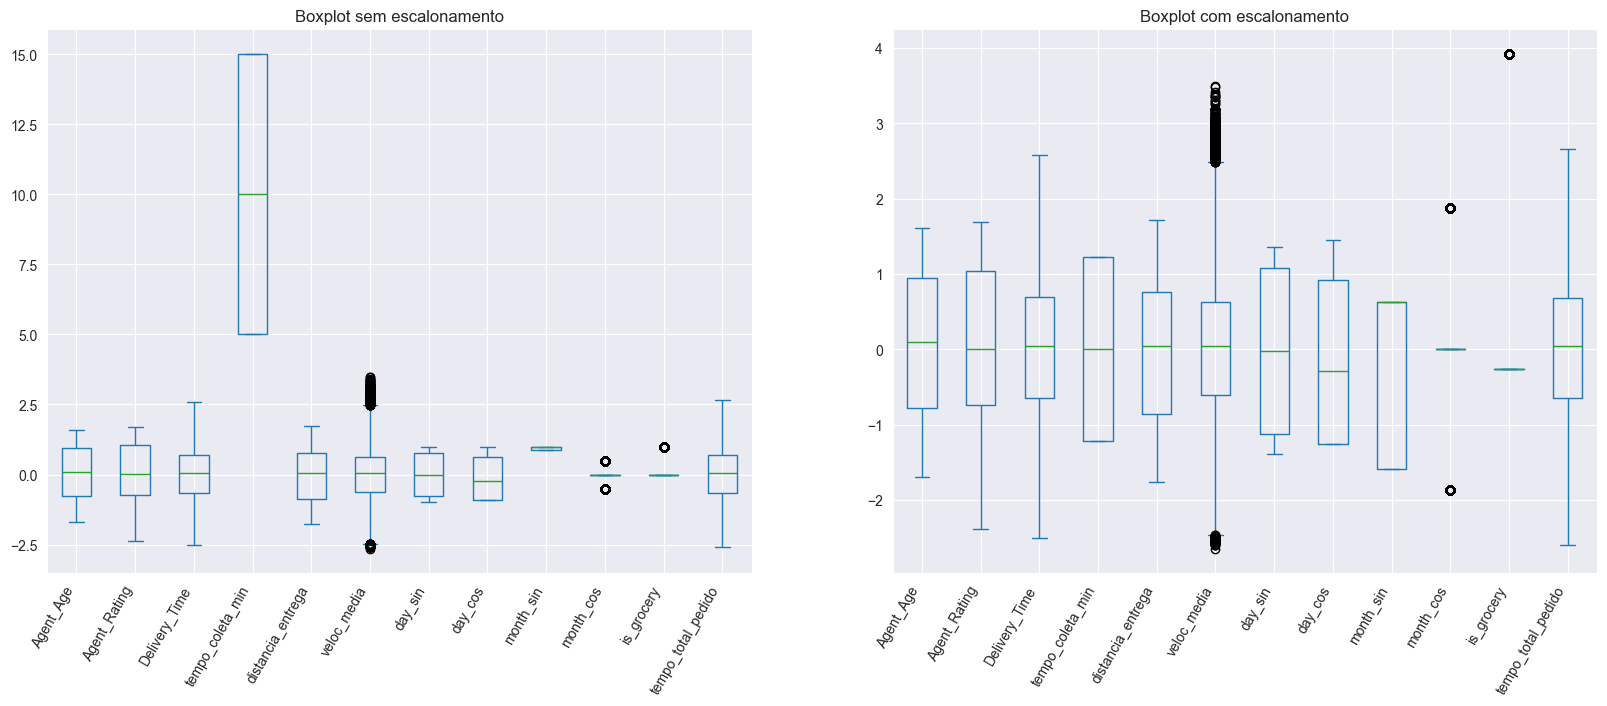

In [48]:
# gráfico boxplot para comparar a distribuição dos dados numericos com o escalonamento
boxplot_comparativo_escalonamento_dados(df=tbl_amazon_dlv_eda.drop(features_encoded.columns,axis=1))

## Remocão dos outliers

In [49]:
# aplicação do método iqr para redução da distribuição em até 3 desvios na feature veloc_media.
tbl_amazon_dlv_eda['veloc_media_outlier'] = verificacao_outlier(tbl_amazon_dlv_eda['veloc_media'])


2025-09-17 01:19:30,363 | INFO | src.visualization.plot | Método de escalonamento: StandardScaler


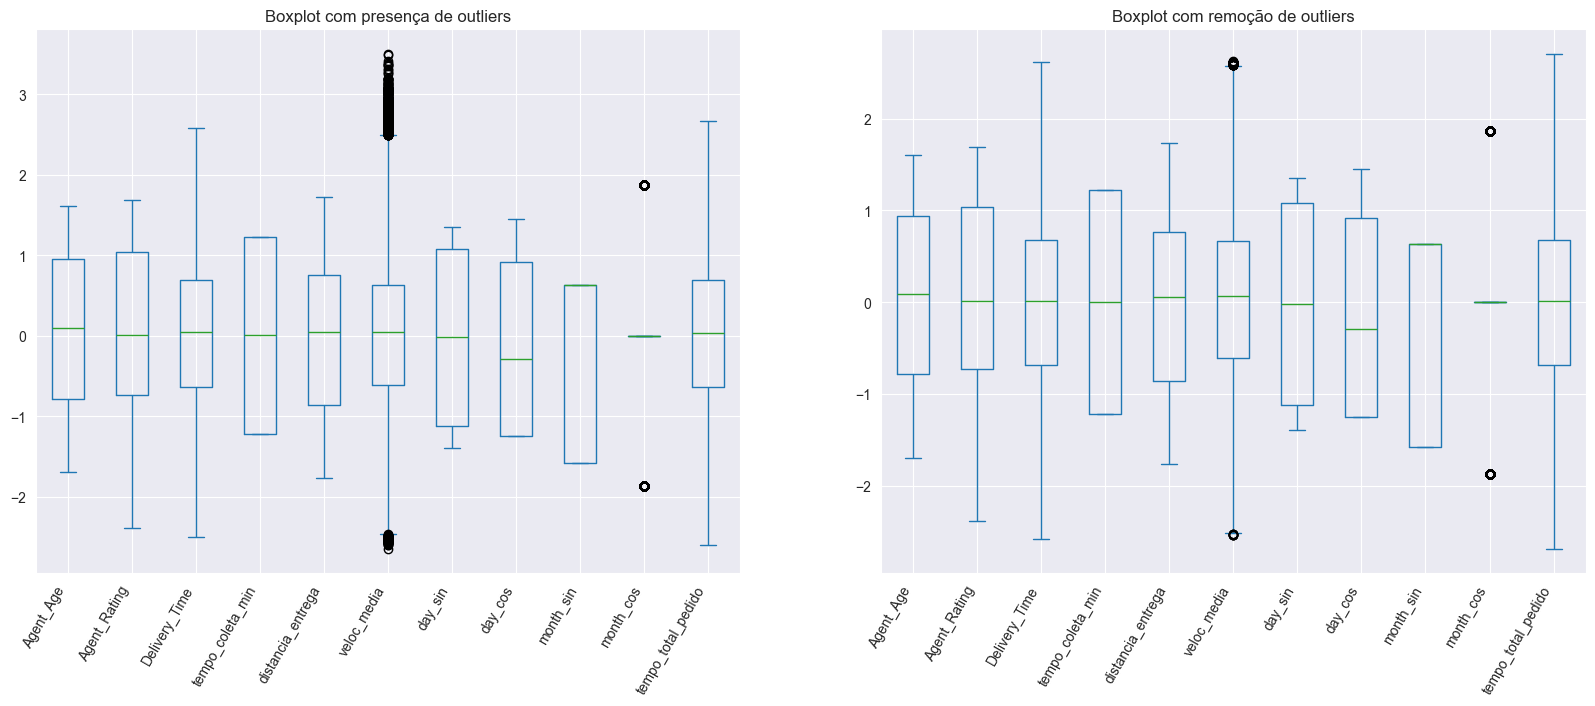

In [53]:
# gráfico boxplot para comparar a distribuição dos dados numericos com o escalonamento
cols_to_plot = ['Agent_Age', 'Agent_Rating', 'Delivery_Time', 
       'tempo_coleta_min', 'distancia_entrega', 'veloc_media', 'day_sin',
       'day_cos', 'month_sin', 'month_cos', 'tempo_total_pedido']

boxplot_comparativo_escalonamento_entre_dfs(
    df1=tbl_amazon_dlv_eda,
    df2=filtrar_dataset(df=tbl_amazon_dlv_eda, query="veloc_media_outlier==False"),
    cols_df1=cols_to_plot,
    cols_df2=cols_to_plot,
    title1='Boxplot com presença de outliers',
    title2='Boxplot com remoção de outliers'
)

In [412]:
# dataset sem a presença outliers.
tbl_amazon_dlv_eda = filtrar_dataset(df=tbl_amazon_dlv_eda, query="veloc_media_outlier==False")

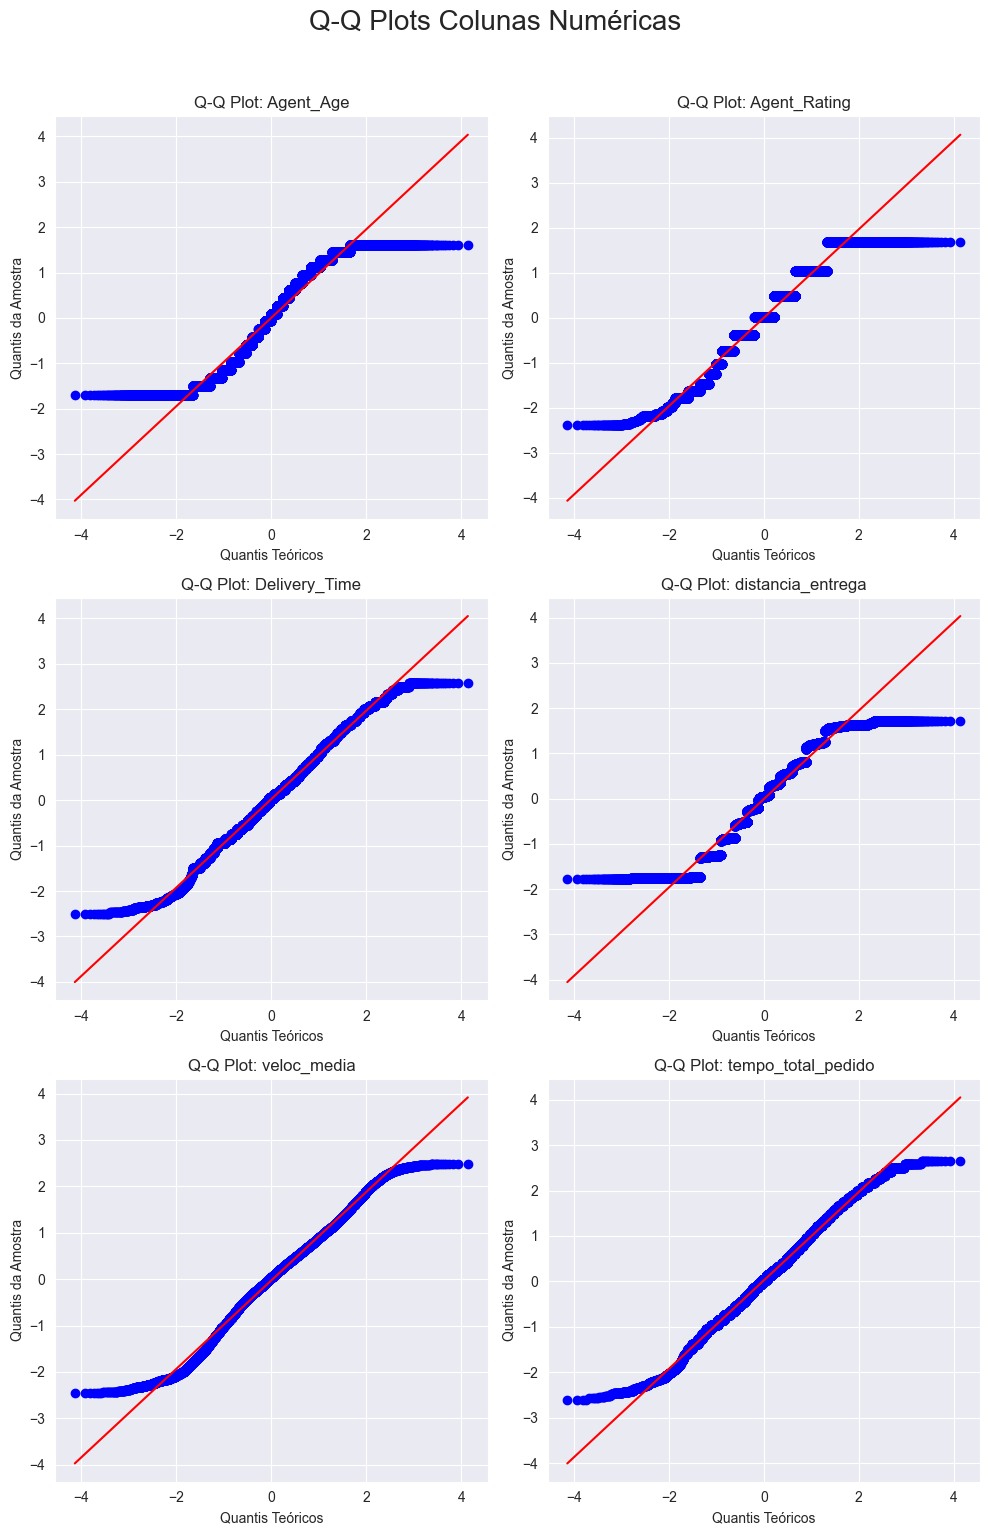

In [414]:
grafico_qq_plot(tbl_amazon_dlv_eda[['Agent_Age','Agent_Rating', 'Delivery_Time', 'distancia_entrega',
       'veloc_media', 'tempo_total_pedido']])

In [415]:
# aplicação de teste estatístico ara validação dos dados
teste_normalidade(df=tbl_amazon_dlv_eda,feature='Delivery_Time', num_cols=['Agent_Age','Agent_Rating', 'Delivery_Time', 'distancia_entrega',
       'veloc_media', 'tempo_total_pedido'])

,Categoria,Coluna,N,Teste,Estatística,p-value,Normal?
0,Geral,Agent_Age,39607,Kolmogorov-Smirnov,0.086404,1.036705e-257,Não
1,Geral,Agent_Rating,39607,Kolmogorov-Smirnov,0.103631,0.000000e+00,Não
2,Geral,Delivery_Time,39607,Kolmogorov-Smirnov,0.035727,2.320868e-44,Não
3,Geral,distancia_entrega,39607,Kolmogorov-Smirnov,0.075039,2.101687e-194,Não
4,Geral,veloc_media,39607,Kolmogorov-Smirnov,0.037299,2.597149e-48,Não
5,Geral,tempo_total_pedido,39607,Kolmogorov-Smirnov,0.031864,2.269761e-35,Não


## análise do target


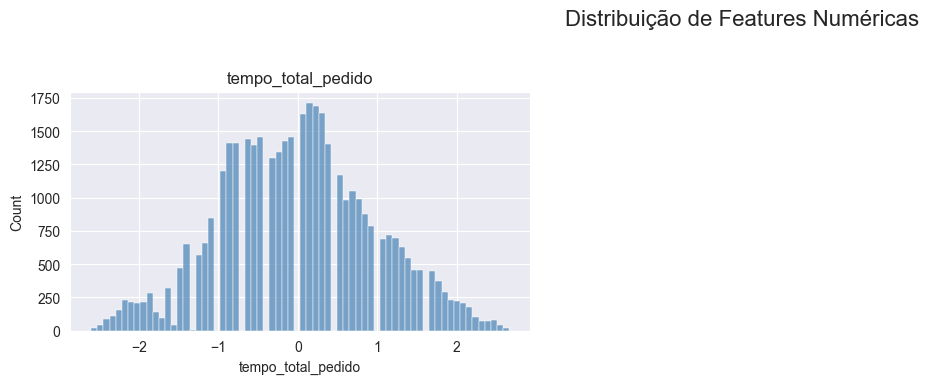

In [416]:
# análise da distribuição dos dados no target
grafico_histograma(df=tbl_amazon_dlv_eda[['tempo_total_pedido']])

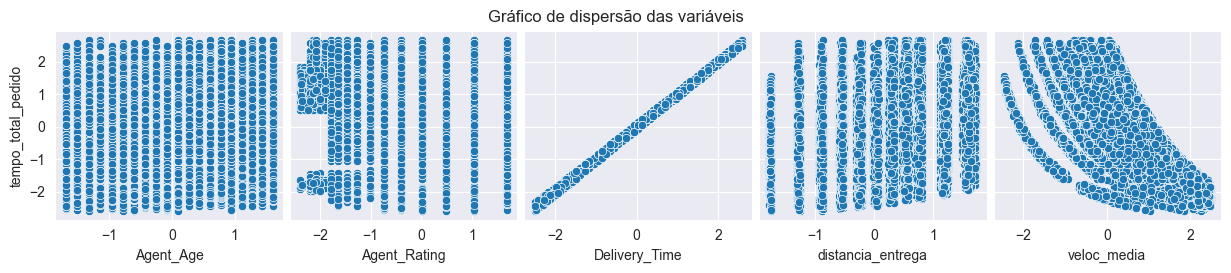

In [417]:
# análise da relação de features preditoras com o target
grafico_pairplot_target(df=tbl_amazon_dlv_eda, target='tempo_total_pedido', lista_features=['Agent_Age','Agent_Rating', 'Delivery_Time', 'distancia_entrega', 
       'veloc_media'], tipo='scatter')

In [418]:
features_selecionadas = ['Agent_Age', 'Agent_Rating','Delivery_Time', 'Category','tempo_coleta_min',
       'distancia_entrega', 'veloc_media','day_sin',
       'day_cos', 'month_sin', 'month_cos','tempo_total_pedido']

In [419]:
# transformação no tipo de dado para float64
tbl_amazon_dlv_eda[features_selecionadas] = tbl_amazon_dlv_eda[features_selecionadas].astype('float64')

In [420]:
features_selecionadas = ['Agent_Age', 'Agent_Rating',
        'distancia_entrega',
         'day_sin', 'day_cos', 'month_sin', 'month_cos','Weather_Cloudy', 
       'Weather_Sunny',  'Traffic_Jam',
       'Traffic_Low', 'is_grocery',
       'Area_Semi-Urban ', 'Area_Urban ', 'Vehicle_motorcycle ',
       'tempo_total_pedido']

In [421]:
tbl_amazon_dlv_eda.is_grocery.value_counts()

is_grocery
0    37600
1     2007
Name: count, dtype: int64

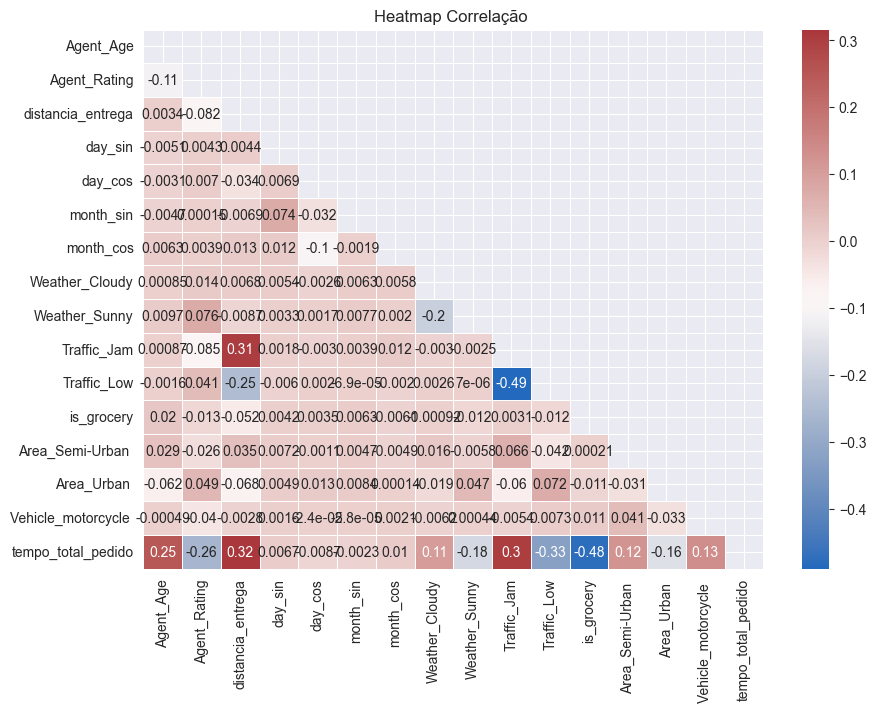

In [422]:
# análise de colinearidade das features com o target
grafico_heatmap(tbl_amazon_dlv_eda[features_selecionadas])


In [424]:
# analise vif para identificar multicolinearidade das features
analise_vif(tbl_amazon_dlv_eda[features_selecionadas].drop('tempo_total_pedido', axis=1), feature='tempo_total_pedido')

,Feature,VIF
5,month_sin,5.128713
14,Vehicle_motorcycle,2.418700
10,Traffic_Low,2.023562
9,Traffic_Jam,2.021642
13,Area_Urban,1.305436
7,Weather_Cloudy,1.252107
8,Weather_Sunny,1.250389
2,distancia_entrega,1.130299
11,is_grocery,1.058063
1,Agent_Rating,1.034128


### Hipóteses e Insights

**Hipótese:  O tempo_total_pedido médio é estatisticamente diferente para cada uma das condições de tráfego**<br>
Há uma diferença na volume das categorias e uma maior correlação das categorias de maior proporção.

In [425]:
# distribuição da feature Traffic
tbl_amazon_dlv.Traffic.value_counts()

Traffic
Low       13739
Jam       12647
Medium     9774
High       3949
Name: count, dtype: int64

In [426]:
# teste anova da feature Traffic de trânsito
teste_anova(tbl_amazon_dlv, formula='tempo_total_pedido~C(Traffic)')

2025-09-17 00:21:51,504 | INFO | src.utils.statistics | Fórmula do modelo: tempo_total_pedido~C(Traffic)
2025-09-17 00:21:51,594 | INFO | src.utils.statistics | 
                 df        sum_sq       mean_sq            F  PR(>F)
C(Traffic)      3.0  1.437286e+07  4.790952e+06  2038.013084     0.0
Residual    40105.0  9.427866e+07  2.350796e+03          NaN     NaN
2025-09-17 00:21:51,595 | INFO | src.utils.statistics | ------------------------------
2025-09-17 00:21:51,595 | INFO | src.utils.statistics | P-valor para o preditor 'Traffic': 0.0000
2025-09-17 00:21:51,596 | INFO | src.utils.statistics | O p-valor é menor que 0.05. Rejeitamos a hipótese nula.
2025-09-17 00:21:51,597 | INFO | src.utils.statistics | Conclusão: Existe uma diferença estatisticamente significativa na média de 'tempo_total_pedido' entre as categorias de 'Traffic'.


**Hipótese: O efeito do tráfego no tempo de entrega não é o mesmo para todos os tipos de clima**.<br>
Podemos criar uma feature combinada entre trafego e clima para melhor exploração desse efeito por parte do modelo.

In [427]:
# teste anova da feature Traffic de trânsito
teste_anova(tbl_amazon_dlv, formula='tempo_total_pedido~C(Weather)*C(Traffic)')

2025-09-17 00:21:51,802 | INFO | src.utils.statistics | Fórmula do modelo: tempo_total_pedido~C(Weather)*C(Traffic)
2025-09-17 00:21:52,040 | INFO | src.utils.statistics | 
                            df        sum_sq       mean_sq            F  PR(>F)
C(Weather)                 5.0  5.122731e+06  1.024546e+06   479.529067     0.0
C(Traffic)                 3.0  1.440342e+07  4.801141e+06  2247.128272     0.0
C(Weather):C(Traffic)     15.0  3.481054e+06  2.320703e+05   108.618280     0.0
Residual               40085.0  8.564431e+07  2.136567e+03          NaN     NaN
2025-09-17 00:21:52,041 | INFO | src.utils.statistics | ------------------------------
2025-09-17 00:21:52,042 | INFO | src.utils.statistics | P-valor para o preditor 'Weather': 0.0000
2025-09-17 00:21:52,042 | INFO | src.utils.statistics | O p-valor é menor que 0.05. Rejeitamos a hipótese nula.
2025-09-17 00:21:52,043 | INFO | src.utils.statistics | Conclusão: Existe uma diferença estatisticamente significativa na média de

**Hipótese: O tempo_total_pedido médio é estatisticamente diferente para cada uma das categorias**<br>
Há uma diferença na volume das categorias e uma maior correlação das categorias de maior proporção.

Após realizar o teste anova, aplicamos o teste de tukey e identificamos que o tempo médio de entrega para categoria grocery é maior que as demais.
Isso é validado através do p-value entre as combinações de todas as categorias. Assim podemos criar uma feature que indique se a compra é ou não uma entrega para a categoria grocery.

In [428]:
# distribuição da feature Traffic
tbl_amazon_dlv.Category.value_counts()

Category
Electronics     2618
Jewelry         2580
Books           2579
Toys            2567
Skincare        2558
Outdoors        2535
Snacks          2518
Apparel         2501
Home            2484
Sports          2481
Pet Supplies    2463
Cosmetics       2454
Grocery         2453
Shoes           2446
Kitchen         2444
Clothing        2428
Name: count, dtype: int64

In [429]:
# teste anova da feature Traffic de trânsito
teste_anova(tbl_amazon_dlv, formula='tempo_total_pedido~C(Category)')

2025-09-17 00:21:52,401 | INFO | src.utils.statistics | Fórmula do modelo: tempo_total_pedido~C(Category)
2025-09-17 00:21:52,542 | INFO | src.utils.statistics | 
                  df        sum_sq       mean_sq          F  PR(>F)
C(Category)     15.0  2.538223e+07  1.692149e+06  814.74615     0.0
Residual     40093.0  8.326928e+07  2.076903e+03        NaN     NaN
2025-09-17 00:21:52,543 | INFO | src.utils.statistics | ------------------------------
2025-09-17 00:21:52,544 | INFO | src.utils.statistics | P-valor para o preditor 'Category': 0.0000
2025-09-17 00:21:52,545 | INFO | src.utils.statistics | O p-valor é menor que 0.05. Rejeitamos a hipótese nula.
2025-09-17 00:21:52,546 | INFO | src.utils.statistics | Conclusão: Existe uma diferença estatisticamente significativa na média de 'tempo_total_pedido' entre as categorias de 'Category'.


In [430]:
import statsmodels.stats.multicomp as mc
comp = mc.MultiComparison(tbl_amazon_dlv['tempo_total_pedido'], tbl_amazon_dlv['Category'])
tabela_tukey = comp.tukeyhsd()

print(tabela_tukey)

         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
   group1       group2     meandiff p-adj    lower     upper   reject
---------------------------------------------------------------------
     Apparel        Books   -0.8893    1.0   -5.2713    3.4928  False
     Apparel     Clothing   -1.5451 0.9985   -5.9937    2.9036  False
     Apparel    Cosmetics    1.1012    1.0   -3.3354    5.5379  False
     Apparel  Electronics   -0.7716    1.0   -5.1376    3.5943  False
     Apparel      Grocery -105.4018    0.0 -109.8389 -100.9647   True
     Apparel         Home   -0.9084    1.0   -5.3316    3.5147  False
     Apparel      Jewelry    -1.473  0.999   -5.8547    2.9086  False
     Apparel      Kitchen    0.2525    1.0   -4.1887    4.6937  False
     Apparel     Outdoors   -0.4426    1.0   -4.8433    3.9582  False
     Apparel Pet Supplies   -0.2193    1.0   -4.6519    4.2132  False
     Apparel        Shoes   -0.8164    1.0   -5.2567     3.624  False
     Apparel     Ski

c:\Users\ederr\Documents\PROJETOS_PYTHON\projetos_fiap\Fase 3\tech_challenge_ml_engineer_phase3\.venv\Lib\site-packages\scipy\integrate\_quadpack_py.py:1264: IntegrationWarning:

The integral is probably divergent, or slowly convergent.



In [468]:
# média do tempo de entrega para a presença de categoria grocery
tbl_amazon_dlv.groupby('is_grocery')['tempo_total_pedido'].mean()

is_grocery
0    141.483562
1      36.56543
Name: tempo_total_pedido, dtype: Float64

# Requisitos para o Pipeline

## **Processo de tratamento: Pipeline + ColumnTransformer + FunctionTransformer**

** Features Numéricas **

** Features Categóricas **

## Dataset para treinamento do modelo

**Features seleciondas**